<a href="https://colab.research.google.com/github/carlapaz066-tech/Modelizado_de_Sistemas_de_IA/blob/main/Final_Con_Dependencias_Pracitica_Unidad_2_Algoritmos_Gen%C3%A9ticos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Problema:**
## **Optimización del Cronograma de una Vivienda**
### **Contexto:**

Una empresa constructora tiene que realizar 10 tareas críticas para entregar una casa (cimientos, muros, techos, instalaciones, etc.). Cada tarea tiene una duración estimada y requiere un número específico de operarios.


### **El Desafío:**

La empresa solo cuenta con una cuadrilla de 10 operarios en total. Si intentamos hacer muchas tareas en paralelo, superaremos ese límite. Si las hacemos todas en serie, la obra tardará meses.

### **Consigna:**

Desarrollar un modelo de Algoritmo Genético (usando PyGAD o DEAP) que encuentre el orden secuencial de inicio de tareas que minimice el tiempo total de la obra (Makespan) sin exceder nunca el límite de 10 operarios por día.

## Pasos para la Resolución (Hoja de Ruta)

**Modelado de Datos:** Crear una estructura (diccionario o lista) que contenga las 10 tareas, su duración en días y la cantidad de operarios necesarios para cada una.

**Definición del Cromosoma:** Determinar cómo representar la solución. Una forma sencilla es un vector de números reales o enteros que represente el "orden de prioridad" o el "día de inicio" de cada tarea.

**Diseño de la Función de Aptitud (Fitness):** La función debe recibir el orden de las tareas y calcular el día final de obra.

***Importante:*** Si en algún día la suma de operarios de las tareas activas supera los 10, la función debe aplicar una penalización drástica (bajar el fitness) para que esa solución sea descartada por el algoritmo.

Como queremos minimizar el tiempo, el fitness podría ser

$$Fitness = \frac{1}{DíasTotales}$$.

**Configuración del GA:** Definir el tamaño de la población (ej. 50 individuos). Elegir el método de selección (Torneo o Ruleta).Establecer una probabilidad de mutación para evitar que todos los cronogramas se vuelvan iguales rápido.

**Ejecución y Monitoreo:** Correr el proceso evolutivo y observar la curva de fitness para verificar que el tiempo total de la obra disminuya con las generaciones.

**Análisis de Resultados:** Mostrar cuál es el orden de tareas óptimo encontrado y confirmar que el uso de operarios sea legal (máximo 10).

**Razonamiento:**

*Piensen que el Algoritmo Genético aquí actúa como un Jefe de Obra virtual. Él va a probar miles de combinaciones de calendarios diferentes. Los que 'rompen' la regla de los operarios mueren rápido; los que logran terminar la casa un par de días antes, tienen hijos y pasan su estrategia a la siguiente generación.*

In [ ]:
# Instalación de las librerías necesarias
!pip install pygad deap matplotlib numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.8/91.8 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.1/93.1 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 866.9/866.9 kB 11.8 MB/s eta 0:00:00


In [ ]:
# Diccionario de tareas: {ID: (Duración, Operarios)}
TASAS_OBRA = {
    0: (5, 4),  # Cimientos
    1: (7, 6),  # Muros
    2: (4, 5),  # Techo
    3: (6, 3),  # Instalaciones
    4: (5, 4),  # Revoque
    5: (4, 3),  # Pisos
    6: (3, 2),  # Pintura
    7: (2, 3),  # Aberturas
    8: (4, 2),  # Electricidad
    9: (2, 2)   # Final de obra
}

MAX_OPERARIOS = 10
NUM_TAREAS = len(TASAS_OBRA)

In [ ]:
import pygad
import numpy as np

# Diccionario de tareas: {ID: (Duración, Operarios)}
TASAS_OBRA = {
    0: (5, 4), # Cimientos
    1: (7, 6), # Muros
    2: (4, 5), # Techo
    3: (6, 3), # Instalaciones
    4: (5, 4), # Revoque
    5: (4, 3), # Pisos
    6: (3, 2), # Pintura
    7: (2, 3), # Aberturas
    8: (4, 2), # Electricidad
    9: (2, 2)  # Final de obra
}

# Definición de dependencias: {Tarea: [Tareas previas necesarias]}
DEPENDENCIAS = {
    1: [0],  # Muros requiere Cimientos
    2: [0,1],  # Techo requiere Muros y Cimientos
    3: [0,1],  # Instalaciones requiere Muros
    4: [0,1,3,8],  # Revoque requiere muros, Instalaciones, electiricidad
    5: [0],  # Piso requiere los cimientos
    6: [0,1,3,8,4],  # Pintura requiere revoque
    7: [0,1],  # Abertura requiere muros, muros, Instalaciones, electiricidad, revoque
    8: [0,1,3],  # Electricidad requiere muros e instalaciones
    9: [0,6,7] # Final requiere Pintura y Aberturas y cimientos
}

MAX_OPERARIOS = 10
NUM_TAREAS = len(TASAS_OBRA)

def fitness_func(ga_instance, solution, solution_idx):
    orden_tareas = np.argsort(solution)
    cronograma_recursos = np.zeros(300) # Max 300 days for resource allocation tracking
    dia_final_obra = 0
    dias_finalizacion = {} # Registro de cuándo termina cada tarea
    total_dependency_violations = 0
    unplaceable_tasks = 0

    for tarea_id in orden_tareas:
        duracion, operarios_req = TASAS_OBRA[tarea_id]

        dia_minimo_inicio = 0
        if tarea_id in DEPENDENCIAS:
            for dep_id in DEPENDENCIAS[tarea_id]:
                if dep_id in dias_finalizacion:
                    dia_minimo_inicio = max(dia_minimo_inicio, dias_finalizacion[dep_id])
                else:
                    total_dependency_violations += 1 # This task's dependencies are not met in order

        dia_inicio = dia_minimo_inicio
        task_scheduled = False
        # Limit the search for a start day to prevent infinite loops for impossible tasks
        # If the task cannot start before the end of the cronograma_recursos, consider it unplaceable
        max_possible_start_day = len(cronograma_recursos) - duracion

        while dia_inicio <= max_possible_start_day:
            ventana = cronograma_recursos[dia_inicio : dia_inicio + duracion]
            if np.all(ventana + operarios_req <= MAX_OPERARIOS):
                cronograma_recursos[dia_inicio : dia_inicio + duracion] += operarios_req
                fin_esta_tarea = dia_inicio + duracion
                dias_finalizacion[tarea_id] = fin_esta_tarea
                if fin_esta_tarea > dia_final_obra:
                    dia_final_obra = fin_esta_tarea
                task_scheduled = True
                break
            dia_inicio += 1

        if not task_scheduled:
            unplaceable_tasks += 1
            # If a task can't be scheduled, the entire schedule is invalid for time calculation
            # We will use this in penalty calculation

    # Fitness calculation
    if total_dependency_violations > 0:
        # High penalty for dependency violations. The more violations, the worse.
        # This makes the GA prioritize fixing dependencies first.
        return 1.0 / (10000.0 + total_dependency_violations * 1000.0) # Larger value -> smaller fitness
    elif unplaceable_tasks > 0:
        # Penalty for tasks that couldn't be scheduled within the 300-day resource array
        return 1.0 / (5000.0 + unplaceable_tasks * 500.0)
    elif dia_final_obra == 0:
        # Should not happen if all tasks are placed but good safeguard
        return 0.00000001
    else:
        # All dependencies met, all tasks scheduled. Minimize makespan.
        return 1.0 / dia_final_obra

# --- Configuración del GA ---
ga_instance = pygad.GA(
    num_generations=300, # Increased generations
    num_parents_mating=10,
    fitness_func=fitness_func,
    sol_per_pop=200, # Increased population size
    num_genes=NUM_TAREAS,
    parent_selection_type="tournament",
    keep_parents=5, # Added to preserve best solutions
    mutation_percent_genes=20 # Slightly increased mutation percentage
)

print("Ejecutando GA con restricciones de precedencia...")
ga_instance.run()

solution, solution_fitness, _ = ga_instance.best_solution()
print(f"Mejor tiempo con dependencias: {1.0 / solution_fitness} días")
print(f"Orden óptimo: {np.argsort(solution)}")

Ejecutando GA con restricciones de precedencia...
Mejor tiempo con dependencias: 32.0 días
Orden óptimo: [0 5 1 3 2 8 4 6 7 9]


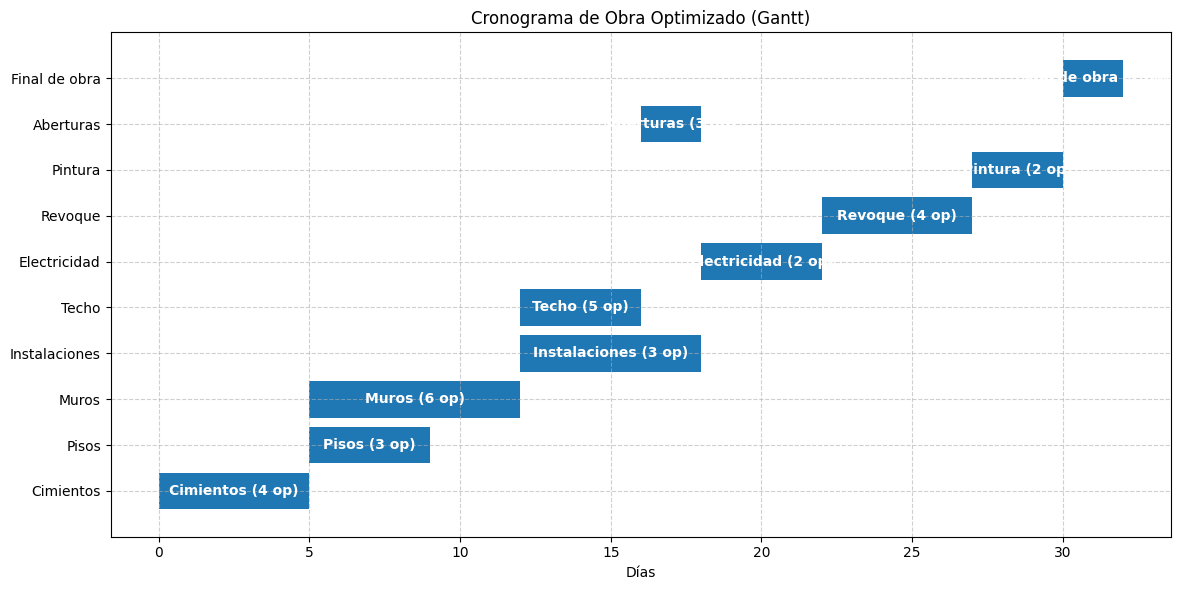

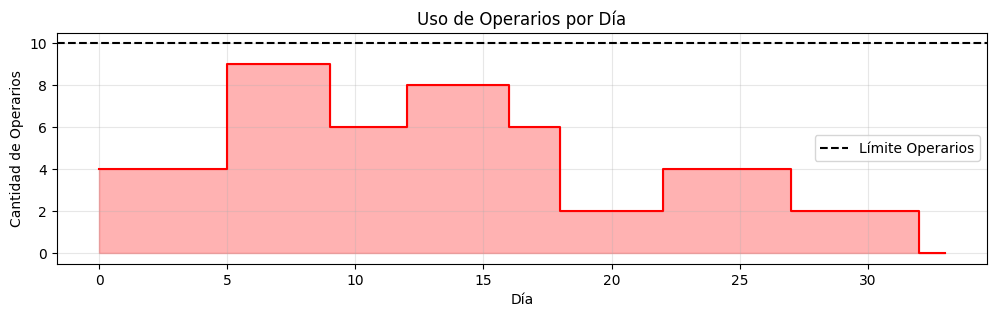

In [ ]:
import matplotlib.pyplot as plt

def plot_gantt(solution):
    orden_tareas = np.argsort(solution)
    cronograma_recursos = np.zeros(300)
    dias_finalizacion = {}
    gantt_data = []

    # Re-calculate the schedule for plotting
    for tarea_id in orden_tareas:
        duracion, operarios_req = TASAS_OBRA[tarea_id]
        dia_minimo_inicio = 0
        if tarea_id in DEPENDENCIAS:
            for dep_id in DEPENDENCIAS[tarea_id]:
                if dep_id in dias_finalizacion:
                    dia_minimo_inicio = max(dia_minimo_inicio, dias_finalizacion[dep_id])

        dia_inicio = dia_minimo_inicio
        while True:
            ventana = cronograma_recursos[dia_inicio : dia_inicio + duracion]
            if np.all(ventana + operarios_req <= MAX_OPERARIOS):
                cronograma_recursos[dia_inicio : dia_inicio + duracion] += operarios_req
                fin_esta_tarea = dia_inicio + duracion
                dias_finalizacion[tarea_id] = fin_esta_tarea
                gantt_data.append((tarea_id, dia_inicio, duracion))
                break
            dia_inicio += 1

    # Plotting
    fig, ax = plt.subplots(figsize=(12, 6))

    # Task names for labels
    nombres_tareas = {
        0: 'Cimientos', 1: 'Muros', 2: 'Techo', 3: 'Instalaciones', 4: 'Revoque',
        5: 'Pisos', 6: 'Pintura', 7: 'Aberturas', 8: 'Electricidad', 9: 'Final de obra'
    }

    for i, (tarea_id, start, duration) in enumerate(gantt_data):
        ax.broken_barh([(start, duration)], (i - 0.4, 0.8), facecolors=('tab:blue'))
        ax.text(start + duration/2, i, f"{nombres_tareas[tarea_id]} ({TASAS_OBRA[tarea_id][1]} op)",
                ha='center', va='center', color='white', fontweight='bold')

    ax.set_ylim(-1, len(TASAS_OBRA))
    ax.set_xlabel('Días')
    ax.set_yticks(range(len(TASAS_OBRA)))
    ax.set_yticklabels([nombres_tareas[item[0]] for item in gantt_data])
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.set_title('Cronograma de Obra Optimizado (Gantt)')

    plt.tight_layout()
    plt.show()

    # Resource usage plot
    plt.figure(figsize=(12, 3))
    plt.step(range(len(cronograma_recursos[:int(max(dias_finalizacion.values()))+2])),
             cronograma_recursos[:int(max(dias_finalizacion.values()))+2], where='post', color='red')
    plt.axhline(y=MAX_OPERARIOS, color='black', linestyle='--', label='Límite Operarios')
    plt.fill_between(range(len(cronograma_recursos[:int(max(dias_finalizacion.values()))+2])),
                     cronograma_recursos[:int(max(dias_finalizacion.values()))+2], step="post", alpha=0.3, color='red')
    plt.title('Uso de Operarios por Día')
    plt.xlabel('Día')
    plt.ylabel('Cantidad de Operarios')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# Visualize the best solution
plot_gantt(solution)

## Si usan PyGAD:

In [ ]:
import pygad
import numpy as np
import matplotlib.pyplot as plt

## Si usan DEAP:

In [ ]:
import random
import numpy as np
from deap import base, creator, tools, algorithms
import matplotlib.pyplot as plt